# KDD Project — Phase 1: Data Acquisition, Target Construction & Routing Classifiers
## Predicting When Stronger Models Win from Prompt Features

This notebook implements Steps 1–3 of our pipeline:
1. **Load & explore** the LMArena Human Preference 140K dataset
2. **Construct the target variable** (`strong_model_won`) using domain-specific Elo ratings
3. **Train routing classifiers** (domain-bucket baseline, TF-IDF + LR, DistilBERT) to predict `strong_model_won` from prompt features

**Environment:** Google Colab (GPU recommended for Step 3)

---
## 0. Setup & Installs

In [1]:
# Run once — install dependencies
!pip install -q datasets transformers accelerate scikit-learn pandas numpy matplotlib seaborn textstat


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("Setup complete.")

Setup complete.


---
## Step 1: Load & Explore the Arena 140K Dataset

In [4]:
from datasets import load_dataset

print("Loading Arena Human Preference 140K dataset...")
arena_ds = load_dataset("lmarena-ai/arena-human-preference-140k", split="train")
print(f"Loaded {len(arena_ds):,} rows")
print(f"Columns: {arena_ds.column_names}")

Loading Arena Human Preference 140K dataset...


Loaded 135,634 rows
Columns: ['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id', 'evaluation_order', 'conversation_a', 'conversation_b', 'full_conversation', 'conv_metadata', 'category_tag', 'language', 'is_code', 'timestamp']


In [5]:
# Convert to pandas for easier exploration
# We avoid loading full conversation text into the DataFrame initially to save memory.
# Instead, we extract just the metadata and first user prompt.

print("Converting to DataFrame (metadata + first prompt only)...")

records = []
for i, row in enumerate(arena_ds):
    # Extract the first user message as the "prompt"
    prompt_text = ""
    if row.get("full_conversation") and len(row["full_conversation"]) > 0:
        first_turn = row["full_conversation"][0]
        if isinstance(first_turn, dict) and "content" in first_turn:
            content = first_turn["content"]
            if isinstance(content, str):
                prompt_text = content
            elif isinstance(content, list):
                prompt_text = " ".join(
                    block.get("text", "") for block in content
                    if isinstance(block, dict) and block.get("type") == "text"
                )
    
    # Fallback: try conversation_a first user turn
    if not prompt_text and row.get("conversation_a") and len(row["conversation_a"]) > 0:
        first_turn = row["conversation_a"][0]
        if isinstance(first_turn, dict) and "content" in first_turn:
            content = first_turn["content"]
            if isinstance(content, str):
                prompt_text = content
            elif isinstance(content, list):
                prompt_text = " ".join(
                    block.get("text", "") for block in content
                    if isinstance(block, dict) and block.get("type") == "text"
                )
    
    # Extract category tags (nested dict of dicts)
    cat_tag = row.get("category_tag", {}) or {}
    creative_writing = cat_tag.get("creative_writing_v0.1", {}) or {}
    criteria = cat_tag.get("criteria_v0.1", {}) or {}
    if_tag = cat_tag.get("if_v0.1", {}) or {}
    math_tag = cat_tag.get("math_v0.1", {}) or {}
    
    # Extract conversation metadata
    meta = row.get("conv_metadata", {}) or {}
    header_a = meta.get("header_count_a", {}) or {}
    header_b = meta.get("header_count_b", {}) or {}
    list_a = meta.get("list_count_a", {}) or {}
    list_b = meta.get("list_count_b", {}) or {}
    bold_a = meta.get("bold_count_a", {}) or {}
    bold_b = meta.get("bold_count_b", {}) or {}
    
    records.append({
        "id": row.get("id", i),
        "model_a": row.get("model_a", ""),
        "model_b": row.get("model_b", ""),
        "winner": row.get("winner", ""),
        "language": row.get("language", ""),
        "is_code": row.get("is_code", False),
        "prompt_text": prompt_text,
        "num_turns_a": len(row.get("conversation_a", [])) // 2,
        "num_turns_b": len(row.get("conversation_b", [])) // 2,
        # Category tags (from nested category_tag dict)
        "cat_math": math_tag.get("math", False),
        "cat_coding": row.get("is_code", False),
        "cat_creative_writing": creative_writing.get("creative_writing", False),
        "cat_instruction_following": if_tag.get("if", False),
        "cat_if_score": if_tag.get("score", None),
        # Criteria tags
        "cat_complexity": criteria.get("complexity", False),
        "cat_creativity": criteria.get("creativity", False),
        "cat_domain_knowledge": criteria.get("domain_knowledge", False),
        "cat_problem_solving": criteria.get("problem_solving", False),
        "cat_real_world": criteria.get("real_world", False),
        "cat_specificity": criteria.get("specificity", False),
        "cat_technical_accuracy": criteria.get("technical_accuracy", False),
        # Conversation metadata — token counts
        "meta_assistant_a_tokens": meta.get("sum_assistant_a_tokens", None),
        "meta_assistant_b_tokens": meta.get("sum_assistant_b_tokens", None),
        "meta_context_a_tokens": meta.get("context_a_tokens", None),
        "meta_context_b_tokens": meta.get("context_b_tokens", None),
        "meta_user_tokens": meta.get("sum_user_tokens", None),
        "meta_turns": meta.get("turns", None),
        # Conversation metadata — formatting (model A)
        "meta_headers_a": sum(header_a.values()),
        "meta_lists_ordered_a": list_a.get("ordered", 0),
        "meta_lists_unordered_a": list_a.get("unordered", 0),
        "meta_bold_a": sum(bold_a.values()),
        # Conversation metadata — formatting (model B)
        "meta_headers_b": sum(header_b.values()),
        "meta_lists_ordered_b": list_b.get("ordered", 0),
        "meta_lists_unordered_b": list_b.get("unordered", 0),
        "meta_bold_b": sum(bold_b.values()),
    })
    
    if (i + 1) % 25000 == 0:
        print(f"  Processed {i+1:,} rows...")

df = pd.DataFrame(records)
print(f"\nDataFrame shape: {df.shape}")
df.head(3)

Converting to DataFrame (metadata + first prompt only)...
  Processed 25,000 rows...


KeyboardInterrupt: 

In [3]:
# Save/load checkpoint for the DataFrame built above.
# After running cell 6 once, you can restart the kernel and skip to this cell.
import os, pandas as pd

checkpoint_path = 'arena_df_checkpoint.parquet'

if os.path.exists(checkpoint_path):
    df = pd.read_parquet(checkpoint_path)
    print(f"Loaded DataFrame from checkpoint: {df.shape}")
else:
    df.to_parquet(checkpoint_path, index=False)
    print(f"Saved DataFrame checkpoint: {df.shape}")

Loaded DataFrame from checkpoint: (135634, 37)


In [4]:
# ---- Structural Audit ----
print("=" * 60)
print("STRUCTURAL AUDIT")
print("=" * 60)

print(f"\n--- Shape: {df.shape[0]:,} rows x {df.shape[1]} columns ---")

print(f"\n--- Winner distribution ---")
print(df['winner'].value_counts())
print(f"\n  Proportions:")
print(df['winner'].value_counts(normalize=True).round(3))

print(f"\n--- Unique models ---")
all_models = set(df['model_a'].unique()) | set(df['model_b'].unique())
print(f"  Total unique models: {len(all_models)}")

print(f"\n--- Top 15 most frequent models ---")
model_counts = pd.concat([df['model_a'], df['model_b']]).value_counts()
print(model_counts.head(15))

print(f"\n--- Language distribution (top 10) ---")
print(df['language'].value_counts().head(10))

print(f"\n--- Category tag frequencies (boolean flags) ---")
cat_bool_cols = [c for c in df.columns if c.startswith('cat_') and c != 'cat_if_score']
for col in cat_bool_cols:
    print(f"  {col}: {df[col].sum():,} ({df[col].mean():.1%})")

print(f"\n--- Instruction-following score distribution ---")
print(df['cat_if_score'].describe().round(2))

print(f"\n--- Metadata coverage ---")
meta_cols = [c for c in df.columns if c.startswith('meta_')]
for col in meta_cols:
    non_null = df[col].notna().sum()
    print(f"  {col}: {non_null:,} non-null ({non_null/len(df):.1%})")

print(f"\n--- Missing/empty prompts ---")
empty_prompts = (df['prompt_text'].isna() | (df['prompt_text'].str.strip() == '')).sum()
print(f"  {empty_prompts:,} rows with empty/missing prompts ({empty_prompts/len(df):.1%})")

print(f"\n--- Prompt length stats (word count) ---")
df['prompt_word_count'] = df['prompt_text'].fillna('').str.split().str.len()
print(df['prompt_word_count'].describe().round(1))

STRUCTURAL AUDIT

--- Shape: 135,634 rows x 37 columns ---

--- Winner distribution ---
winner
model_b     49785
model_a     48563
tie         21532
both_bad    15754
Name: count, dtype: int64

  Proportions:
winner
model_b     0.367
model_a     0.358
tie         0.159
both_bad    0.116
Name: proportion, dtype: float64

--- Unique models ---
  Total unique models: 53

--- Top 15 most frequent models ---
claude-opus-4-20250514                     10092
gemini-2.5-flash                            9668
gemini-2.5-pro                              9219
mistral-medium-2505                         9135
qwen3-235b-a22b-no-thinking                 9076
o3-2025-04-16                               8529
claude-sonnet-4-20250514                    8295
chatgpt-4o-latest-20250326                  7650
gemma-3-27b-it                              7326
claude-3-7-sonnet-20250219-thinking-32k     7149
claude-3-7-sonnet-20250219                  6852
command-a-03-2025                           6838
claud

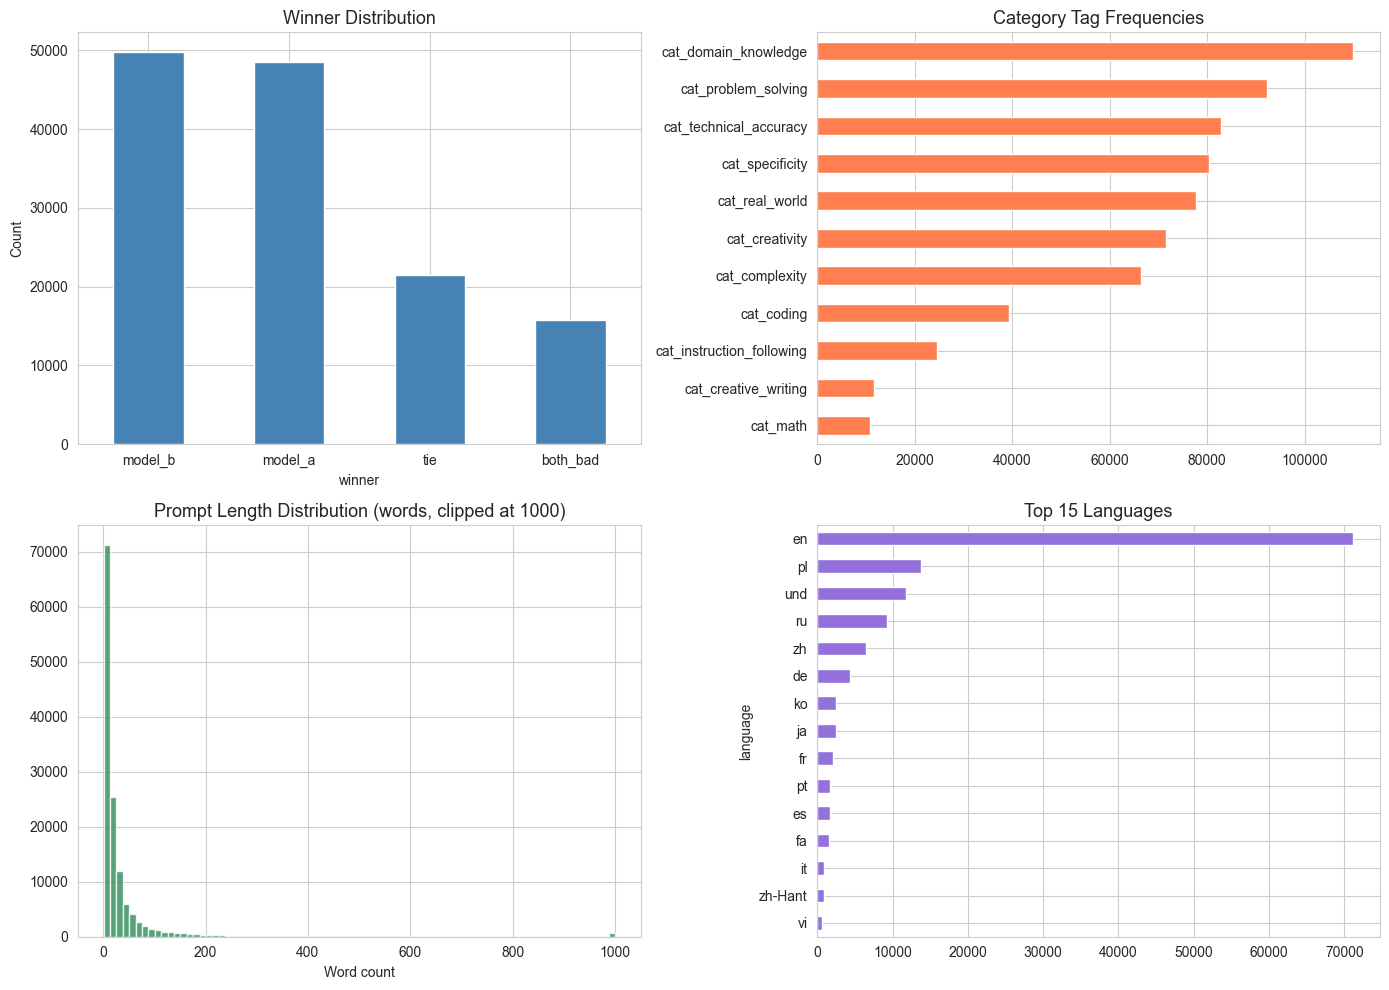

In [5]:
# ---- Visualize key distributions ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Winner distribution
df['winner'].value_counts().plot.bar(ax=axes[0, 0], color='steelblue', edgecolor='white')
axes[0, 0].set_title('Winner Distribution', fontsize=13)
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Category tag frequencies (boolean columns only)
cat_bool_cols = [c for c in df.columns if c.startswith('cat_') and c != 'cat_if_score']
cat_sums = df[cat_bool_cols].sum().sort_values(ascending=True)
cat_sums.plot.barh(ax=axes[0, 1], color='coral', edgecolor='white')
axes[0, 1].set_title('Category Tag Frequencies', fontsize=13)

# 3. Prompt length distribution (log scale for visibility)
df['prompt_word_count'].clip(upper=1000).hist(
    bins=80, ax=axes[1, 0], color='seagreen', edgecolor='white', alpha=0.8
)
axes[1, 0].set_title('Prompt Length Distribution (words, clipped at 1000)', fontsize=13)
axes[1, 0].set_xlabel('Word count')

# 4. Top 15 languages
df['language'].value_counts().head(15).plot.barh(
    ax=axes[1, 1], color='mediumpurple', edgecolor='white'
)
axes[1, 1].set_title('Top 15 Languages', fontsize=13)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

### Step 1 Findings

**Document your observations here after running the cells above.** Key things to note:
- What's the tie rate? (This affects class balance of the target)
- How many `both_bad` votes are there? (These get excluded)
- Are the category tags sparse or dense? (Affects Tier 1 feature utility)
- Any surprises in the model or language distributions?

---
## Step 2: Construct the Target Variable

We need Elo ratings for each model to determine "stronger" vs "weaker" in each battle.

**Strategy:** We compute Elo ratings directly from the battle outcomes in our dataset using the Bradley-Terry model (same approach used by Chatbot Arena). This is self-contained and reproducible — no external API dependency.

In [6]:
# ---- Assign each battle to a domain bucket for categorical Elo ----
# We use the Arena's own boolean category tags for bucketing.
# A battle can have multiple tags; we use a priority order to pick one bucket.
# Priority: code > math > creative_writing > chat (default)

def assign_domain_bucket(row):
    """Assign a battle to a single domain bucket using priority rules."""
    if row.get('cat_coding', False) or row.get('is_code', False):
        return 'code'
    elif row.get('cat_math', False):
        return 'math_science'
    elif row.get('cat_creative_writing', False):
        return 'creative_writing'
    else:
        return 'chat'

df['domain_bucket'] = df.apply(assign_domain_bucket, axis=1)

print("--- Domain bucket distribution ---")
print(df['domain_bucket'].value_counts())
print(f"\nProportions:")
print(df['domain_bucket'].value_counts(normalize=True).round(3))

--- Domain bucket distribution ---
domain_bucket
chat                77437
code                39363
creative_writing    10799
math_science         8035
Name: count, dtype: int64

Proportions:
domain_bucket
chat                0.571
code                0.290
creative_writing    0.080
math_science        0.059
Name: proportion, dtype: float64


In [7]:
# ---- Compute GLOBAL + CATEGORICAL Elo ratings ----
# Global Elo: computed from all battles (same as before)
# Categorical Elo: computed separately within each domain bucket
# Fallback: if a model has < MIN_BATTLES in a category, use global Elo

from collections import defaultdict

MIN_BATTLES_PER_CATEGORY = 50  # Minimum battles to trust a categorical rating

def compute_elo_ratings(battles_df, K=32, initial_rating=1500, num_rounds=5):
    """
    Compute Elo ratings by replaying battles multiple times (bootstrap-style)
    and averaging. This gives more stable ratings than a single pass.
    """
    all_ratings = defaultdict(list)
    
    for round_i in range(num_rounds):
        shuffled = battles_df.sample(frac=1, random_state=round_i).reset_index(drop=True)
        ratings = defaultdict(lambda: initial_rating)
        
        for _, row in shuffled.iterrows():
            a, b = row['model_a'], row['model_b']
            ra, rb = ratings[a], ratings[b]
            
            ea = 1 / (1 + 10 ** ((rb - ra) / 400))
            eb = 1 - ea
            
            if row['winner'] == 'model_a':
                sa, sb = 1.0, 0.0
            elif row['winner'] == 'model_b':
                sa, sb = 0.0, 1.0
            else:
                sa, sb = 0.5, 0.5
            
            ratings[a] += K * (sa - ea)
            ratings[b] += K * (sb - eb)
        
        for model, rating in ratings.items():
            all_ratings[model].append(rating)
    
    return {model: np.mean(scores) for model, scores in all_ratings.items()}


# --- Compute global Elo ---
battles_for_elo = df[df['winner'] != 'both_bad'].copy()
print(f"Computing GLOBAL Elo from {len(battles_for_elo):,} battles...")
elo_global = compute_elo_ratings(battles_for_elo, K=32, num_rounds=10)

# --- Compute categorical Elo per domain ---
DOMAINS = ['code', 'math_science', 'creative_writing', 'chat']
elo_by_domain = {}
domain_battle_counts = {}  # track model battle counts per domain

for domain in DOMAINS:
    domain_battles = battles_for_elo[battles_for_elo['domain_bucket'] == domain]
    print(f"\nComputing {domain.upper()} Elo from {len(domain_battles):,} battles...")
    
    # Track how many battles each model has in this domain
    model_counts = pd.concat([domain_battles['model_a'], domain_battles['model_b']]).value_counts()
    domain_battle_counts[domain] = model_counts.to_dict()
    
    if len(domain_battles) >= 100:  # Need enough battles for stable ratings
        elo_by_domain[domain] = compute_elo_ratings(domain_battles, K=32, num_rounds=10)
    else:
        print(f"  WARNING: Only {len(domain_battles)} battles — using global Elo as fallback")
        elo_by_domain[domain] = elo_global.copy()

# --- Build a combined Elo lookup with fallback ---
def get_domain_elo(model, domain):
    """Get domain-specific Elo, falling back to global if insufficient data."""
    battle_count = domain_battle_counts.get(domain, {}).get(model, 0)
    if battle_count >= MIN_BATTLES_PER_CATEGORY and domain in elo_by_domain:
        return elo_by_domain[domain].get(model, elo_global.get(model, 1500))
    else:
        return elo_global.get(model, 1500)

# --- Display global rankings ---
elo_df = pd.DataFrame([
    {'model': m, 'elo_global': r} for m, r in elo_global.items()
]).sort_values('elo_global', ascending=False).reset_index(drop=True)

print(f"\nComputed Elo for {len(elo_df)} models.")
print("\n--- Top 20 models by GLOBAL Elo ---")
print(elo_df.head(20).to_string(index=False))

Computing GLOBAL Elo from 119,880 battles...

Computing CODE Elo from 34,666 battles...

Computing MATH_SCIENCE Elo from 6,935 battles...

Computing CREATIVE_WRITING Elo from 9,268 battles...

Computing CHAT Elo from 69,011 battles...

Computed Elo for 53 models.

--- Top 20 models by GLOBAL Elo ---
                                       model  elo_global
                              gemini-2.5-pro 1654.140113
                gemini-2.5-pro-preview-03-25 1620.436500
                gemini-2.5-pro-preview-05-06 1616.223192
                               o3-2025-04-16 1614.813122
         llama-4-maverick-03-26-experimental 1610.517330
                                 grok-4-0709 1603.948125
                            deepseek-r1-0528 1564.799734
                  chatgpt-4o-latest-20250326 1564.490229
                            gemini-2.5-flash 1561.809104
                        grok-3-preview-02-24 1557.641889
              gemini-2.5-flash-preview-04-17 1543.869051
               

In [9]:
# ---- Compare global vs categorical rankings ----
# This is the key diagnostic: do rankings change across domains?

# Build a comparison table for models with enough data in all domains
comparison_rows = []
for model in elo_global.keys():
    row = {'model': model, 'global': elo_global[model]}
    has_all = True
    for domain in DOMAINS:
        count = domain_battle_counts.get(domain, {}).get(model, 0)
        if count >= MIN_BATTLES_PER_CATEGORY and domain in elo_by_domain:
            row[domain] = elo_by_domain[domain].get(model, np.nan)
            row[f'{domain}_n'] = count
        else:
            row[domain] = np.nan
            row[f'{domain}_n'] = count
            has_all = False
    row['has_all_domains'] = has_all
    comparison_rows.append(row)

elo_compare = pd.DataFrame(comparison_rows)

# Show ranking shifts for models with data in all domains
full_coverage = elo_compare[elo_compare['has_all_domains']].copy()
print(f"Models with >= {MIN_BATTLES_PER_CATEGORY} battles in ALL domains: {len(full_coverage)}")

if len(full_coverage) > 0:
    # Compute rank in each domain
    full_coverage['rank_global'] = full_coverage['global'].rank(ascending=False).astype(int)
    for domain in DOMAINS:
        full_coverage[f'rank_{domain}'] = full_coverage[domain].rank(ascending=False).astype(int)
    
    # Show the models with biggest rank shifts
    rank_cols = ['rank_global'] + [f'rank_{d}' for d in DOMAINS]
    full_coverage['max_rank_shift'] = full_coverage[rank_cols].max(axis=1) - full_coverage[rank_cols].min(axis=1)
    
    display_cols = ['model', 'rank_global', 'rank_code', 'rank_math_science', 'rank_chat', 'max_rank_shift']
    display_cols = [c for c in display_cols if c in full_coverage.columns]
    
    print("\n--- Top 20 models by global rank (with domain ranks) ---")
    print(full_coverage.sort_values('rank_global')[display_cols].head(20).to_string(index=False))
    
    print(f"\n--- Biggest rank shifts (models that change rank the most across domains) ---")
    print(full_coverage.sort_values('max_rank_shift', ascending=False)[display_cols].head(15).to_string(index=False))
    
    # Rank correlation between domains (Kendall's tau)
    from scipy.stats import kendalltau
    print("\n--- Kendall's tau rank correlation between domains ---")
    for i, d1 in enumerate(DOMAINS):
        for d2 in DOMAINS[i+1:]:
            col1, col2 = f'rank_{d1}', f'rank_{d2}'
            if col1 in full_coverage.columns and col2 in full_coverage.columns:
                tau, pval = kendalltau(full_coverage[col1], full_coverage[col2])
                print(f"  {d1} vs {d2}: tau={tau:.3f}, p={pval:.4f}")
else:
    print("Not enough models with full domain coverage. Lowering MIN_BATTLES_PER_CATEGORY may help.")

Models with >= 50 battles in ALL domains: 48

--- Top 20 models by global rank (with domain ranks) ---
                                       model  rank_global  rank_code  rank_math_science  rank_chat  max_rank_shift
                              gemini-2.5-pro            1          2                  2          1               1
                gemini-2.5-pro-preview-03-25            2          5                  1          6               5
                gemini-2.5-pro-preview-05-06            3         11                  9          4               8
                               o3-2025-04-16            4          3                 11          2               9
         llama-4-maverick-03-26-experimental            5          7                  7          9               4
                                 grok-4-0709            6          1                  3          3               7
                            deepseek-r1-0528            7          9                 15     

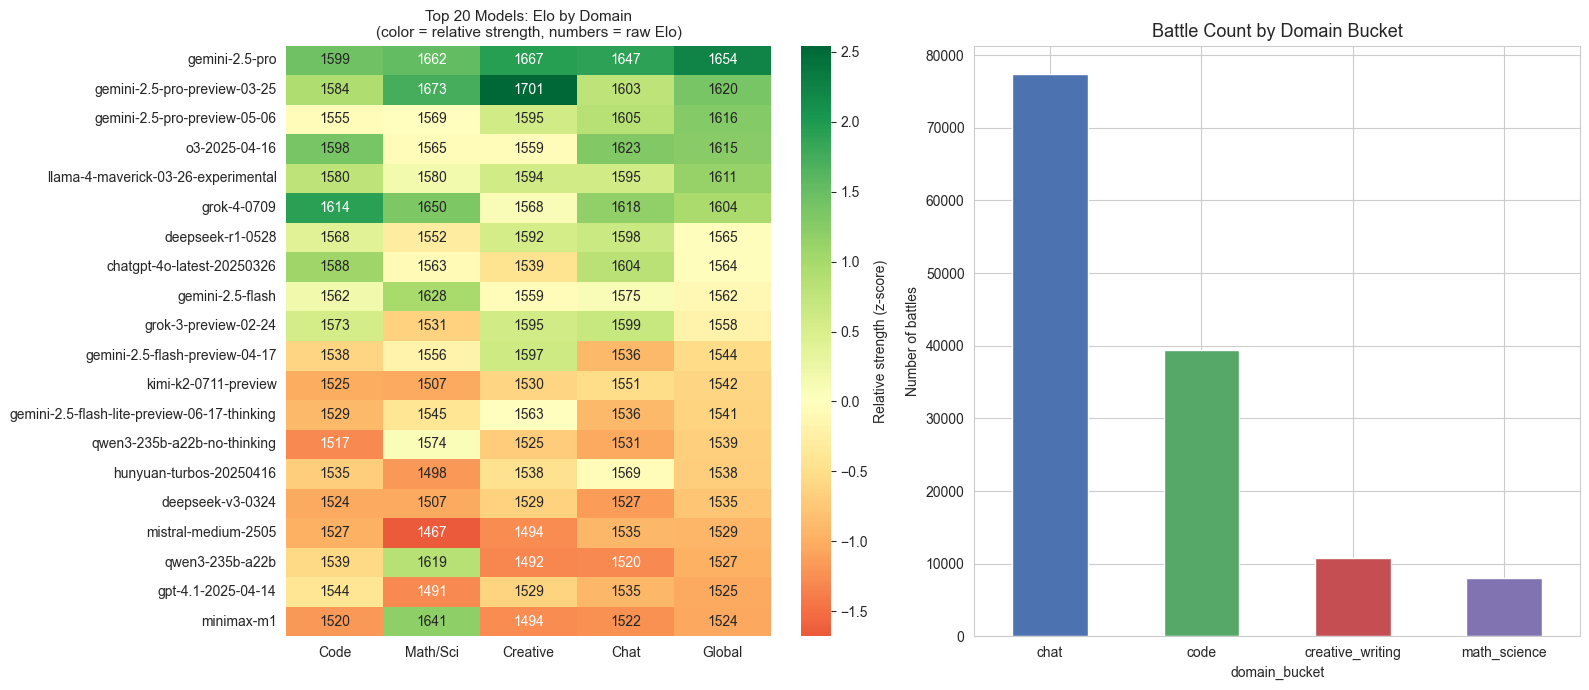

In [10]:
# ---- Visualize domain Elo differences ----

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Heatmap of top models' Elo across domains
if len(full_coverage) >= 5:
    top_models = full_coverage.sort_values('rank_global').head(20)
    heatmap_data = top_models.set_index('model')[DOMAINS + ['global']].copy()
    
    # Normalize each column to show relative standing (z-score within column)
    heatmap_norm = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()
    
    sns.heatmap(
        heatmap_norm, annot=heatmap_data.round(0).astype(int), fmt='d',
        cmap='RdYlGn', center=0, ax=axes[0],
        xticklabels=['Code', 'Math/Sci', 'Creative', 'Chat', 'Global'],
        cbar_kws={'label': 'Relative strength (z-score)'}
    )
    axes[0].set_title('Top 20 Models: Elo by Domain\n(color = relative strength, numbers = raw Elo)', fontsize=11)
    axes[0].set_ylabel('')

# 2. Domain bucket sizes
bucket_counts = df['domain_bucket'].value_counts()
bucket_counts.plot.bar(ax=axes[1], color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'], edgecolor='white')
axes[1].set_title('Battle Count by Domain Bucket', fontsize=13)
axes[1].set_ylabel('Number of battles')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# ---- Construct the target variable using DOMAIN-SPECIFIC Elo ----
# Key change: "stronger model" is determined by the Elo rating in the
# RELEVANT domain, not the global Elo. This means the "stronger" model
# in a coding battle may differ from the "stronger" model in a chat battle.

df_clean = df[df['winner'] != 'both_bad'].copy()
print(f"Removed both_bad: {len(df):,} -> {len(df_clean):,} rows")

# Map BOTH global and domain-specific Elo to each battle
df_clean['elo_global_a'] = df_clean['model_a'].map(elo_global)
df_clean['elo_global_b'] = df_clean['model_b'].map(elo_global)
df_clean['elo_global_gap'] = (df_clean['elo_global_a'] - df_clean['elo_global_b']).abs()

# Domain-specific Elo (uses fallback to global if insufficient data)
df_clean['elo_domain_a'] = df_clean.apply(
    lambda r: get_domain_elo(r['model_a'], r['domain_bucket']), axis=1
)
df_clean['elo_domain_b'] = df_clean.apply(
    lambda r: get_domain_elo(r['model_b'], r['domain_bucket']), axis=1
)
df_clean['elo_domain_gap'] = (df_clean['elo_domain_a'] - df_clean['elo_domain_b']).abs()

# Determine stronger model using DOMAIN Elo (primary target)
df_clean['stronger_model_domain'] = np.where(
    df_clean['elo_domain_a'] >= df_clean['elo_domain_b'], 'model_a', 'model_b'
)
df_clean['stronger_model_name'] = np.where(
    df_clean['elo_domain_a'] >= df_clean['elo_domain_b'], df_clean['model_a'], df_clean['model_b']
)
df_clean['weaker_model_name'] = np.where(
    df_clean['elo_domain_a'] >= df_clean['elo_domain_b'], df_clean['model_b'], df_clean['model_a']
)

# PRIMARY target: domain-specific
df_clean['strong_model_won'] = (
    df_clean['winner'] == df_clean['stronger_model_domain']
).astype(int)

# COMPARISON target: what would global Elo say?
df_clean['stronger_model_global'] = np.where(
    df_clean['elo_global_a'] >= df_clean['elo_global_b'], 'model_a', 'model_b'
)
df_clean['strong_model_won_global'] = (
    df_clean['winner'] == df_clean['stronger_model_global']
).astype(int)

# How often do domain and global Elo disagree about who's stronger?
disagree_mask = df_clean['stronger_model_domain'] != df_clean['stronger_model_global']
print(f"\nDomain vs Global Elo DISAGREE on stronger model: "
      f"{disagree_mask.sum():,} / {len(df_clean):,} battles ({disagree_mask.mean():.1%})")
print(f"  (These are battles where categorical Elo changes the target label)")

print(f"\n--- Target distribution (domain Elo) ---")
print(df_clean['strong_model_won'].value_counts(normalize=True).round(3))

print(f"\n--- Target distribution (global Elo, for comparison) ---")
print(df_clean['strong_model_won_global'].value_counts(normalize=True).round(3))

Removed both_bad: 135,634 -> 119,880 rows

Domain vs Global Elo DISAGREE on stronger model: 14,116 / 119,880 battles (11.8%)
  (These are battles where categorical Elo changes the target label)

--- Target distribution (domain Elo) ---
strong_model_won
1    0.518
0    0.482
Name: proportion, dtype: float64

--- Target distribution (global Elo, for comparison) ---
strong_model_won_global
1    0.515
0    0.485
Name: proportion, dtype: float64


Domain Elo gap distribution:
count    119880.0
mean         83.1
std          59.7
min           0.0
25%          37.2
50%          70.3
75%         122.9
max         367.8
Name: elo_domain_gap, dtype: float64


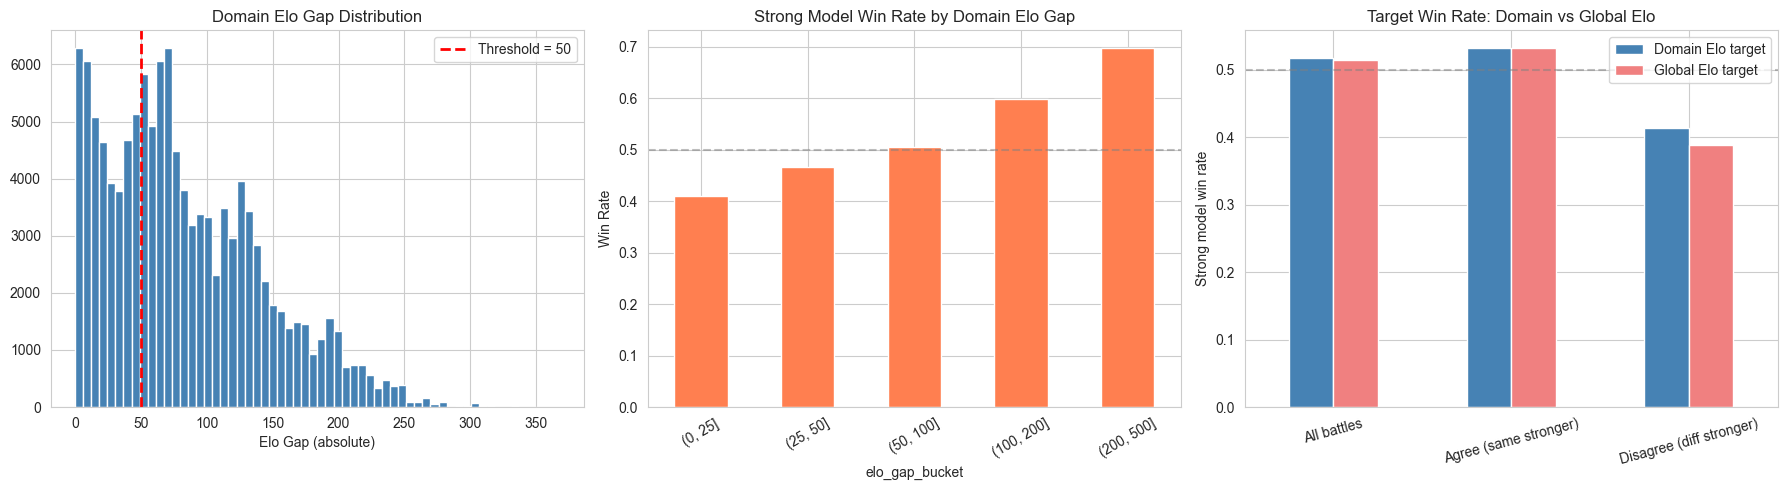


Comparison table:
                          Domain Elo target  Global Elo target
All battles                           0.518              0.515
Agree (same stronger)                 0.532              0.532
Disagree (diff stronger)              0.413              0.388


In [12]:
# Step 2e: Apply minimum Elo gap filter (using DOMAIN Elo gap)

MIN_ELO_GAP = 50

print(f"Domain Elo gap distribution:")
print(df_clean['elo_domain_gap'].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Domain Elo gap distribution
df_clean['elo_domain_gap'].clip(upper=500).hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(MIN_ELO_GAP, color='red', linestyle='--', linewidth=2, label=f'Threshold = {MIN_ELO_GAP}')
axes[0].set_title('Domain Elo Gap Distribution')
axes[0].set_xlabel('Elo Gap (absolute)')
axes[0].legend()

# 2. Win rate by domain elo gap bucket
df_clean['elo_gap_bucket'] = pd.cut(df_clean['elo_domain_gap'], bins=[0, 25, 50, 100, 200, 500, 2000])
win_by_gap = df_clean.groupby('elo_gap_bucket', observed=True)['strong_model_won'].agg(['mean', 'count'])
win_by_gap['mean'].plot.bar(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Strong Model Win Rate by Domain Elo Gap')
axes[1].set_ylabel('Win Rate')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=30)

# 3. COMPARISON — domain vs global Elo target agreement by gap
# In the disagreement zone, which target is more "correct"?
agree = df_clean[~disagree_mask]
disagree = df_clean[disagree_mask]

comparison_data = pd.DataFrame({
    'Domain Elo target': [
        df_clean['strong_model_won'].mean(),
        agree['strong_model_won'].mean() if len(agree) > 0 else np.nan,
        disagree['strong_model_won'].mean() if len(disagree) > 0 else np.nan,
    ],
    'Global Elo target': [
        df_clean['strong_model_won_global'].mean(),
        agree['strong_model_won_global'].mean() if len(agree) > 0 else np.nan,
        disagree['strong_model_won_global'].mean() if len(disagree) > 0 else np.nan,
    ]
}, index=['All battles', 'Agree (same stronger)', 'Disagree (diff stronger)'])

comparison_data.plot.bar(ax=axes[2], color=['steelblue', 'lightcoral'], edgecolor='white')
axes[2].set_title('Target Win Rate: Domain vs Global Elo')
axes[2].set_ylabel('Strong model win rate')
axes[2].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nComparison table:")
print(comparison_data.round(3).to_string())

In [13]:
# Apply the filter using DOMAIN Elo gap
df_filtered = df_clean[df_clean['elo_domain_gap'] >= MIN_ELO_GAP].copy()
print(f"After domain Elo gap >= {MIN_ELO_GAP} filter: {len(df_clean):,} -> {len(df_filtered):,} rows")

print(f"\n--- Final target distribution (domain Elo) ---")
print(df_filtered['strong_model_won'].value_counts())
print(f"\n  Proportions:")
print(df_filtered['strong_model_won'].value_counts(normalize=True).round(3))

print(f"\n--- For comparison: global Elo target ---")
print(df_filtered['strong_model_won_global'].value_counts(normalize=True).round(3))

# Win rate by category — now using domain-aware target
print(f"\n--- Win rate by category (DOMAIN Elo target) ---")
cat_bool_cols = [c for c in df_filtered.columns if c.startswith('cat_') and c != 'cat_if_score']
for col in cat_bool_cols:
    subset = df_filtered[df_filtered[col] == True]
    if len(subset) > 100:
        rate_domain = subset['strong_model_won'].mean()
        rate_global = subset['strong_model_won_global'].mean()
        diff = rate_domain - rate_global
        print(f"  {col}: domain={rate_domain:.1%}  global={rate_global:.1%}  "
              f"delta={diff:+.1%}  (n={len(subset):,})")

# Win rate by domain bucket
print(f"\n--- Win rate by domain bucket ---")
for bucket in DOMAINS:
    subset = df_filtered[df_filtered['domain_bucket'] == bucket]
    if len(subset) > 100:
        rate = subset['strong_model_won'].mean()
        print(f"  {bucket}: {rate:.1%} of {len(subset):,} battles")

After domain Elo gap >= 50 filter: 119,880 -> 79,437 rows

--- Final target distribution (domain Elo) ---
strong_model_won
1    44482
0    34955
Name: count, dtype: int64

  Proportions:
strong_model_won
1    0.56
0    0.44
Name: proportion, dtype: float64

--- For comparison: global Elo target ---
strong_model_won_global
1    0.556
0    0.444
Name: proportion, dtype: float64

--- Win rate by category (DOMAIN Elo target) ---
  cat_math: domain=55.0%  global=53.4%  delta=+1.6%  (n=6,166)
  cat_coding: domain=54.9%  global=54.6%  delta=+0.3%  (n=21,180)
  cat_creative_writing: domain=57.2%  global=56.7%  delta=+0.6%  (n=6,478)
  cat_instruction_following: domain=54.6%  global=54.2%  delta=+0.4%  (n=13,949)
  cat_complexity: domain=56.0%  global=55.5%  delta=+0.5%  (n=38,089)
  cat_creativity: domain=57.0%  global=56.7%  delta=+0.3%  (n=41,968)
  cat_domain_knowledge: domain=56.6%  global=56.2%  delta=+0.4%  (n=64,386)
  cat_problem_solving: domain=56.6%  global=56.3%  delta=+0.3%  (n=53,

In [14]:
# Save the processed Arena dataset as a checkpoint
df_filtered.drop(columns=['elo_gap_bucket'], errors='ignore').to_parquet('arena_processed_step2.parquet', index=False)
print(f"Saved checkpoint: arena_processed_step2.parquet ({len(df_filtered):,} rows)")

Saved checkpoint: arena_processed_step2.parquet (79,437 rows)


### Step 2 Findings

**Document your observations here.** Key things to note:
- Do the global Elo rankings look reasonable? Do domain-specific rankings fix the issues you saw (e.g., does Claude 4 Opus rank higher in code/math)?
- How often do domain and global Elo disagree about who's "stronger"? (The disagreement rate tells you how much categorical Elo matters)
- In the battles where they disagree, which target has a higher win rate? (Higher = more predictive = better target)
- What does Kendall's tau between domains tell you? Low tau = models have genuinely different strengths = horizontal routing is real
- Does win rate increase more cleanly with domain Elo gap than global Elo gap?

---
## Step 3: Train Routing Classifiers (Predict `strong_model_won`)

**Goal:** Train classifiers that predict whether the stronger model (by domain Elo) will win a given battle, using only prompt-level features. We compare:
1. **Baseline** — per-domain-bucket majority-class prediction
2. **TF-IDF + Logistic Regression** — classical ML on prompt text + category features
3. **DistilBERT** — fine-tuned transformer on prompt text

All models are trained on the Arena dataset itself. The target `strong_model_won` was constructed in Step 2 using domain-specific Elo ratings.

In [1]:
# Load Step 2 checkpoint so Step 3 can run independently
import os, pandas as pd

step2_checkpoint = 'arena_processed_step2.parquet'

if os.path.exists(step2_checkpoint):
    df_filtered = pd.read_parquet(step2_checkpoint)
    print(f"Loaded Step 2 checkpoint: {df_filtered.shape}")
else:
    print(f"No checkpoint found at '{step2_checkpoint}' — run Step 2 first, or continue from above.")


Loaded Step 2 checkpoint: (79437, 49)


In [2]:
# ---- Train / Val / Test Split ----
from sklearn.model_selection import train_test_split

# 80/10/10 split, stratified by target
train_df, temp_df = train_test_split(
    df_filtered, test_size=0.2, random_state=42,
    stratify=df_filtered['strong_model_won']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42,
    stratify=temp_df['strong_model_won']
)

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
print(f"\nClass balance (strong_model_won):")
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    rate = split['strong_model_won'].mean()
    print(f"  {name}: {rate:.3f} positive ({split['strong_model_won'].sum():,} / {len(split):,})")

Train: 63,549  Val: 7,944  Test: 7,944

Class balance (strong_model_won):
  Train: 0.560 positive (35,585 / 63,549)
  Val: 0.560 positive (4,449 / 7,944)
  Test: 0.560 positive (4,448 / 7,944)


### 3A: Baseline — Domain Bucket Majority-Class Prediction

For each domain bucket, we compute the training-set win rate of `strong_model_won`. If > 0.5 we predict 1 (strong wins); otherwise 0. This is the simplest possible routing heuristic: only the domain matters.

In [3]:
# ---- Domain-bucket baseline ----
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Compute per-bucket win rate on training data
bucket_win_rates = train_df.groupby('domain_bucket')['strong_model_won'].mean()
print("Training-set win rates by domain bucket:")
print(bucket_win_rates.round(3))
print()

# Predict: majority class per bucket
bucket_pred_map = (bucket_win_rates > 0.5).astype(int).to_dict()
y_pred_baseline = test_df['domain_bucket'].map(bucket_pred_map).values
y_true = test_df['strong_model_won'].values

baseline_acc = accuracy_score(y_true, y_pred_baseline)
baseline_f1 = f1_score(y_true, y_pred_baseline, average='macro')

print(f"Domain-Bucket Baseline  |  Accuracy: {baseline_acc:.4f}  |  Macro F1: {baseline_f1:.4f}")
print()
print(classification_report(y_true, y_pred_baseline, target_names=["strong_lost", "strong_won"]))

Training-set win rates by domain bucket:
domain_bucket
chat                0.565
code                0.547
creative_writing    0.575
math_science        0.547
Name: strong_model_won, dtype: float64

Domain-Bucket Baseline  |  Accuracy: 0.5599  |  Macro F1: 0.3589

              precision    recall  f1-score   support

 strong_lost       0.00      0.00      0.00      3496
  strong_won       0.56      1.00      0.72      4448

    accuracy                           0.56      7944
   macro avg       0.28      0.50      0.36      7944
weighted avg       0.31      0.56      0.40      7944



C:\Users\Alex\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alex\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alex\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

### 3B: TF-IDF + Logistic Regression

We vectorize prompt text with TF-IDF and append the native category boolean tags as extra features, then train a logistic regression classifier.

In [4]:
# ---- TF-IDF + Logistic Regression ----
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack, csr_matrix

# TF-IDF on prompt text
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), max_df=0.95, min_df=5)
X_train_tfidf = tfidf.fit_transform(train_df['prompt_text'].fillna(''))
X_val_tfidf = tfidf.transform(val_df['prompt_text'].fillna(''))
X_test_tfidf = tfidf.transform(test_df['prompt_text'].fillna(''))

# Append native category tags as extra features
cat_feature_cols = [
    'cat_math', 'cat_coding', 'cat_creative_writing',
    'cat_instruction_following',
    'cat_complexity', 'cat_creativity', 'cat_domain_knowledge',
    'cat_problem_solving', 'cat_real_world', 'cat_specificity',
    'cat_technical_accuracy',
    'is_code',
]
# Keep only columns that exist
cat_feature_cols = [c for c in cat_feature_cols if c in train_df.columns]

X_train_cat = csr_matrix(train_df[cat_feature_cols].fillna(0).astype(float).values)
X_val_cat = csr_matrix(val_df[cat_feature_cols].fillna(0).astype(float).values)
X_test_cat = csr_matrix(test_df[cat_feature_cols].fillna(0).astype(float).values)

X_train_combined = hstack([X_train_tfidf, X_train_cat])
X_val_combined = hstack([X_val_tfidf, X_val_cat])
X_test_combined = hstack([X_test_tfidf, X_test_cat])

y_train = train_df['strong_model_won'].values
y_val = val_df['strong_model_won'].values

# Train logistic regression
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
lr.fit(X_train_combined, y_train)

y_pred_lr_val = lr.predict(X_val_combined)
y_pred_lr_test = lr.predict(X_test_combined)

lr_acc = accuracy_score(y_true, y_pred_lr_test)
lr_f1 = f1_score(y_true, y_pred_lr_test, average='macro')

print(f"TF-IDF + LR  |  Accuracy: {lr_acc:.4f}  |  Macro F1: {lr_f1:.4f}")
print(f"Val accuracy: {accuracy_score(y_val, y_pred_lr_val):.4f}")
print()
print(classification_report(y_true, y_pred_lr_test, target_names=["strong_lost", "strong_won"]))

TF-IDF + LR  |  Accuracy: 0.5438  |  Macro F1: 0.5007
Val accuracy: 0.5486

              precision    recall  f1-score   support

 strong_lost       0.47      0.28      0.35      3496
  strong_won       0.57      0.75      0.65      4448

    accuracy                           0.54      7944
   macro avg       0.52      0.52      0.50      7944
weighted avg       0.53      0.54      0.52      7944



### 3C: DistilBERT Classifier

We fine-tune DistilBERT on the Arena prompt text for binary classification of `strong_model_won`. This requires a GPU.

In [5]:
# ---- DistilBERT setup ----
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

class PromptDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE = 32

train_dataset = PromptDataset(train_df['prompt_text'].fillna(''), train_df['strong_model_won'], tokenizer)
val_dataset = PromptDataset(val_df['prompt_text'].fillna(''), val_df['strong_model_won'], tokenizer)
test_dataset = PromptDataset(test_df['prompt_text'].fillna(''), test_df['strong_model_won'], tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

C:\Users\Alex\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7265.51it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train batches: 1986 | Val batches: 249 | Test batches: 249


In [6]:
# ---- DistilBERT training loop ----
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

best_val_acc = 0.0
patience_counter = 0
PATIENCE = 2
history = {'train_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    # ---- Train ----
    model.train()
    total_loss = 0
    for batch_i, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        if (batch_i + 1) % 200 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)

    # ---- Validate ----
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += len(labels)

    val_acc = correct / total
    history['val_acc'].append(val_acc)
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_routing_model.pt')
        print(f"  -> New best! Saved model.")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

  Epoch 1 | Batch 200/1986 | Loss: 0.6591
  Epoch 1 | Batch 400/1986 | Loss: 0.6775
  Epoch 1 | Batch 600/1986 | Loss: 0.6875
  Epoch 1 | Batch 800/1986 | Loss: 0.6939
  Epoch 1 | Batch 1000/1986 | Loss: 0.6451
  Epoch 1 | Batch 1200/1986 | Loss: 0.7339
  Epoch 1 | Batch 1400/1986 | Loss: 0.7115
  Epoch 1 | Batch 1600/1986 | Loss: 0.6771
  Epoch 1 | Batch 1800/1986 | Loss: 0.6538

Epoch 1/3 | Train Loss: 0.6860 | Val Acc: 0.5621
  -> New best! Saved model.
  Epoch 2 | Batch 200/1986 | Loss: 0.6844
  Epoch 2 | Batch 400/1986 | Loss: 0.7255
  Epoch 2 | Batch 600/1986 | Loss: 0.6930
  Epoch 2 | Batch 800/1986 | Loss: 0.7057
  Epoch 2 | Batch 1000/1986 | Loss: 0.6787
  Epoch 2 | Batch 1200/1986 | Loss: 0.6773
  Epoch 2 | Batch 1400/1986 | Loss: 0.6330
  Epoch 2 | Batch 1600/1986 | Loss: 0.6875
  Epoch 2 | Batch 1800/1986 | Loss: 0.7138

Epoch 2/3 | Train Loss: 0.6802 | Val Acc: 0.5639
  -> New best! Saved model.
  Epoch 3 | Batch 200/1986 | Loss: 0.6417
  Epoch 3 | Batch 400/1986 | Loss: 0

In [8]:
import numpy as np

# ---- Evaluate DistilBERT on test set ----
model.load_state_dict(torch.load('best_routing_model.pt'))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = probs.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

y_pred_bert = np.array(all_preds)
bert_probs = np.array(all_probs)

bert_acc = accuracy_score(y_true, y_pred_bert)
bert_f1 = f1_score(y_true, y_pred_bert, average='macro')

print("=" * 60)
print("DISTILBERT ROUTING CLASSIFIER — TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy: {bert_acc:.4f}  |  Macro F1: {bert_f1:.4f}")
print()
print(classification_report(y_true, y_pred_bert, target_names=["strong_lost", "strong_won"]))

DISTILBERT ROUTING CLASSIFIER — TEST SET RESULTS
Accuracy: 0.5641  |  Macro F1: 0.4189

              precision    recall  f1-score   support

 strong_lost       0.53      0.07      0.13      3496
  strong_won       0.57      0.95      0.71      4448

    accuracy                           0.56      7944
   macro avg       0.55      0.51      0.42      7944
weighted avg       0.55      0.56      0.45      7944



### 3D: Model Comparison

                 Model  Accuracy  Macro F1
Domain-Bucket Baseline  0.559919  0.358941
           TF-IDF + LR  0.543807  0.500706
            DistilBERT  0.564074  0.418862


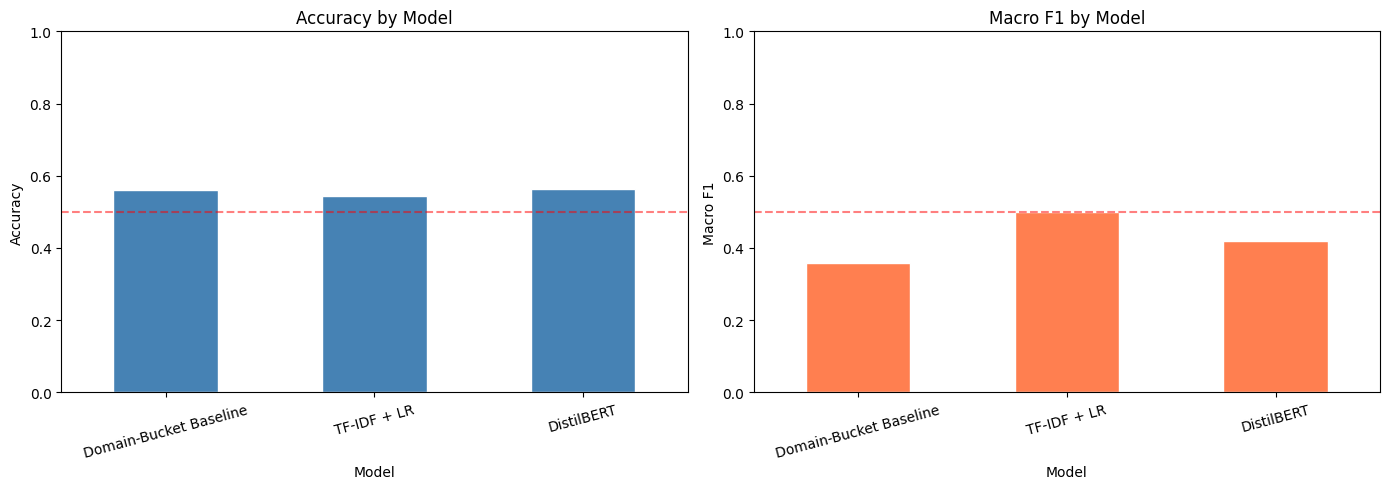


--- Accuracy by domain bucket (test set) ---

chat (n=4735):
  Baseline:   0.5597
  TF-IDF+LR:  0.5436
  DistilBERT: 0.5630

code (n=2121):
  Baseline:   0.5611
  TF-IDF+LR:  0.5384
  DistilBERT: 0.5653

creative_writing (n=574):
  Baseline:   0.5679
  TF-IDF+LR:  0.5889
  DistilBERT: 0.5801

math_science (n=514):
  Baseline:   0.5486
  TF-IDF+LR:  0.5175
  DistilBERT: 0.5506


In [10]:
import matplotlib.pyplot as plt

# ---- Compare all three classifiers ----
results = pd.DataFrame({
    'Model': ['Domain-Bucket Baseline', 'TF-IDF + LR', 'DistilBERT'],
    'Accuracy': [baseline_acc, lr_acc, bert_acc],
    'Macro F1': [baseline_f1, lr_f1, bert_f1],
})
print(results.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results.set_index('Model')[['Accuracy']].plot.bar(
    ax=axes[0], color='steelblue', edgecolor='white', legend=False
)
axes[0].set_title('Accuracy by Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='random')
axes[0].tick_params(axis='x', rotation=15)

results.set_index('Model')[['Macro F1']].plot.bar(
    ax=axes[1], color='coral', edgecolor='white', legend=False
)
axes[1].set_title('Macro F1 by Model')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='random')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ---- Per-domain breakdown ----
print("\n--- Accuracy by domain bucket (test set) ---")
for domain in sorted(test_df['domain_bucket'].unique()):
    mask = test_df['domain_bucket'].values == domain
    n = mask.sum()
    yt = y_true[mask]
    print(f"\n{domain} (n={n}):")
    print(f"  Baseline:   {accuracy_score(yt, y_pred_baseline[mask]):.4f}")
    print(f"  TF-IDF+LR:  {accuracy_score(yt, y_pred_lr_test[mask]):.4f}")
    print(f"  DistilBERT: {accuracy_score(yt, y_pred_bert[mask]):.4f}")

--- DistilBERT vs Baseline agreement ---
  Both correct:          4,226 (53.2%)
  DistilBERT only:       255 (3.2%)
  Baseline only:         222 (2.8%)
  Both wrong:            3,241 (40.8%)


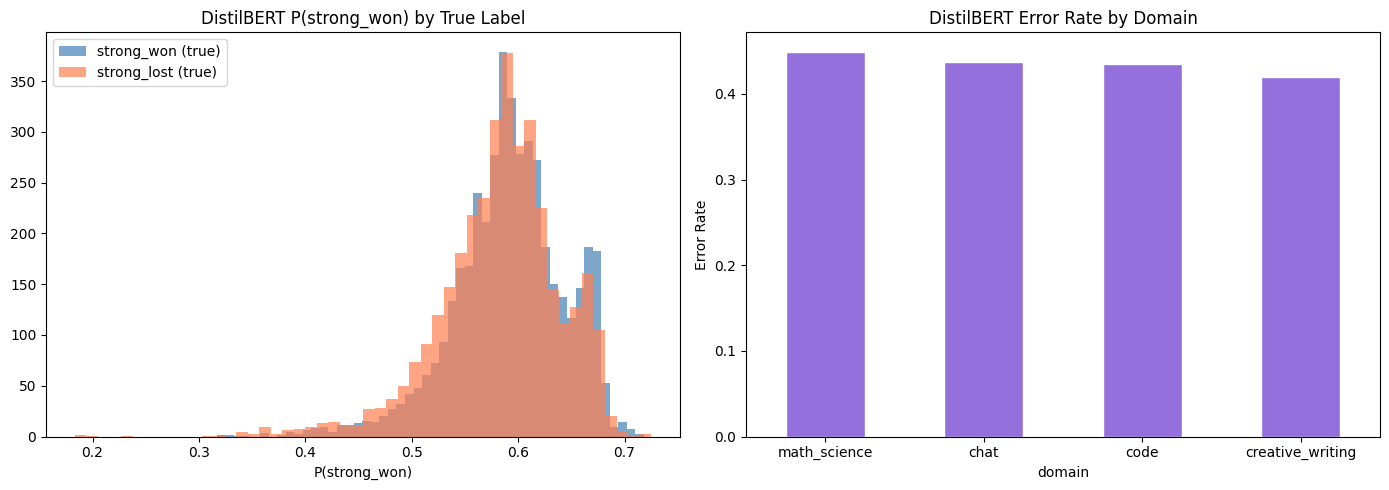

In [11]:
# ---- Error analysis ----

# Where does DistilBERT get it right but baseline doesn't?
bert_right = (y_pred_bert == y_true)
baseline_right = (y_pred_baseline == y_true)

bert_only = bert_right & ~baseline_right
baseline_only = ~bert_right & baseline_right
both_right = bert_right & baseline_right
both_wrong = ~bert_right & ~baseline_right

print("--- DistilBERT vs Baseline agreement ---")
print(f"  Both correct:          {both_right.sum():,} ({both_right.mean():.1%})")
print(f"  DistilBERT only:       {bert_only.sum():,} ({bert_only.mean():.1%})")
print(f"  Baseline only:         {baseline_only.sum():,} ({baseline_only.mean():.1%})")
print(f"  Both wrong:            {both_wrong.sum():,} ({both_wrong.mean():.1%})")

# DistilBERT confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(bert_probs[y_true == 1], bins=50, alpha=0.7, label='strong_won (true)', color='steelblue')
axes[0].hist(bert_probs[y_true == 0], bins=50, alpha=0.7, label='strong_lost (true)', color='coral')
axes[0].set_title('DistilBERT P(strong_won) by True Label')
axes[0].set_xlabel('P(strong_won)')
axes[0].legend()

# Per-domain error rates
domain_errors = []
for domain in sorted(test_df['domain_bucket'].unique()):
    mask = test_df['domain_bucket'].values == domain
    domain_errors.append({
        'domain': domain,
        'n': mask.sum(),
        'bert_error_rate': 1 - accuracy_score(y_true[mask], y_pred_bert[mask]),
    })
domain_err_df = pd.DataFrame(domain_errors).sort_values('bert_error_rate', ascending=False)
domain_err_df.set_index('domain')['bert_error_rate'].plot.bar(
    ax=axes[1], color='mediumpurple', edgecolor='white'
)
axes[1].set_title('DistilBERT Error Rate by Domain')
axes[1].set_ylabel('Error Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [12]:
# ---- Save the enriched dataset ----

# Derive primary_category from native tags (same priority as domain_bucket but finer)
def assign_primary_category(row):
    if row.get('cat_coding', False) or row.get('is_code', False):
        return 'coding'
    elif row.get('cat_math', False):
        return 'math'
    elif row.get('cat_creative_writing', False):
        return 'creative_writing'
    elif row.get('cat_instruction_following', False):
        return 'instruction_following'
    else:
        return 'general'

df_filtered['primary_category'] = df_filtered.apply(assign_primary_category, axis=1)
print(f"Primary category distribution:")
print(df_filtered['primary_category'].value_counts())

output_cols = [
    'id', 'model_a', 'model_b', 'winner', 'language', 'is_code',
    'prompt_text', 'num_turns_a', 'num_turns_b',
    # Category tags (from Arena dataset)
    'cat_math', 'cat_coding', 'cat_creative_writing',
    'cat_instruction_following', 'cat_if_score',
    'cat_complexity', 'cat_creativity', 'cat_domain_knowledge',
    'cat_problem_solving', 'cat_real_world', 'cat_specificity',
    'cat_technical_accuracy',
    # Conversation metadata
    'meta_assistant_a_tokens', 'meta_assistant_b_tokens',
    'meta_context_a_tokens', 'meta_context_b_tokens',
    'meta_user_tokens', 'meta_turns',
    'meta_headers_a', 'meta_lists_ordered_a', 'meta_lists_unordered_a', 'meta_bold_a',
    'meta_headers_b', 'meta_lists_ordered_b', 'meta_lists_unordered_b', 'meta_bold_b',
    'domain_bucket', 'primary_category',
    # Global Elo
    'elo_global_a', 'elo_global_b', 'elo_global_gap',
    # Domain Elo
    'elo_domain_a', 'elo_domain_b', 'elo_domain_gap',
    # Target variables
    'stronger_model_name', 'weaker_model_name',
    'strong_model_won',          # PRIMARY (domain Elo)
    'strong_model_won_global',   # COMPARISON (global Elo)
    'prompt_word_count',
]
# Only include columns that exist
output_cols = [c for c in output_cols if c in df_filtered.columns]

df_filtered[output_cols].to_parquet('arena_enriched_phase1.parquet', index=False)
print(f"Saved: arena_enriched_phase1.parquet")
print(f"Shape: {df_filtered[output_cols].shape}")
print(f"Columns: {output_cols}")

Primary category distribution:
primary_category
general                  41551
coding                   21180
creative_writing          6051
instruction_following     5986
math                      4669
Name: count, dtype: int64
Saved: arena_enriched_phase1.parquet
Shape: (79437, 48)
Columns: ['id', 'model_a', 'model_b', 'winner', 'language', 'is_code', 'prompt_text', 'num_turns_a', 'num_turns_b', 'cat_math', 'cat_coding', 'cat_creative_writing', 'cat_instruction_following', 'cat_if_score', 'cat_complexity', 'cat_creativity', 'cat_domain_knowledge', 'cat_problem_solving', 'cat_real_world', 'cat_specificity', 'cat_technical_accuracy', 'meta_assistant_a_tokens', 'meta_assistant_b_tokens', 'meta_context_a_tokens', 'meta_context_b_tokens', 'meta_user_tokens', 'meta_turns', 'meta_headers_a', 'meta_lists_ordered_a', 'meta_lists_unordered_a', 'meta_bold_a', 'meta_headers_b', 'meta_lists_ordered_b', 'meta_lists_unordered_b', 'meta_bold_b', 'domain_bucket', 'primary_category', 'elo_global_a', '

---
## Phase 1 Summary & Next Steps

### What we built:
1. **Loaded and audited** the Arena 140K dataset — confirmed structure, identified winner distribution, model coverage, and category tag coverage.
2. **Constructed the target variable** (`strong_model_won`) by computing domain-specific Elo ratings from battle data and filtering to meaningful Elo gaps (≥50 points).
3. **Trained routing classifiers** to predict `strong_model_won` directly from prompt features:
   - Domain-bucket baseline (majority-class per domain)
   - TF-IDF + Logistic Regression (prompt text + native category tags)
   - DistilBERT (fine-tuned on prompt text)

### Key deliverables:
- `arena_enriched_phase1.parquet` — the Arena dataset with target variable, Elo ratings, and native category features.
- Three trained routing classifiers with comparative evaluation.

### What comes next (Phase 2):
- **Tier 2 feature extraction** (constraint count, readability, keyword detection, etc.)
- **Tier 3 features** (sentence-transformer embeddings, response divergence)
- **Full EDA** on the enriched dataset
- **XGBoost routing model** with richer features
- **Evaluation** with cost-performance curves